# COMP0051 – Algorithmic Trading Coursework 2025/26

**Starting Capital:** $10,000 USDT  
**Gross Exposure Cap:** $100,000 USDT (max 10× leverage)  
**Assets:** BTC/USDT, ETH/USDT, DOGE/USDT  
**Data Source:** Binance via `python-binance`  

---

## 0. Environment Setup

In [1]:
# Install required packages (run once)
# !pip install python-binance pandas numpy matplotlib seaborn pyarrow statsmodels scipy pandas_datareader requests

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from datetime import datetime, timedelta
import os

# Binance client
from binance.client import Client

# Stats / econometrics
from statsmodels.tsa.stattools import coint, adfuller
from statsmodels.regression.linear_model import OLS
import statsmodels.api as sm
from scipy.optimize import minimize

# Plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('tab10')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 12

# ── Binance API (public endpoints only – no key needed for historical OHLCV) ──
client = Client()  # no API key required for market data

print('All imports OK.')

All imports OK.


---
## 1. Data Download and Visualization.

### 1.1 Download HLOCV data from Binance

In [3]:
# ── Parameters ────────────────────────────────────────────────────────────────
SYMBOLS   = ['BTCUSDT', 'ETHUSDT', 'DOGEUSDT']
INTERVAL  = Client.KLINE_INTERVAL_1HOUR   # 1-hour bars
START_STR = '1 Jan, 2023'
END_STR   = '1 Jan, 2025'
DATA_DIR  = 'data'
os.makedirs(DATA_DIR, exist_ok=True)

KLINE_COLS = [
    'open_time', 'open', 'high', 'low', 'close', 'volume',
    'close_time', 'quote_asset_volume', 'num_trades',
    'taker_buy_base_vol', 'taker_buy_quote_vol', 'ignore'
]

def download_ohlcv(symbol: str, interval: str, start: str, end: str) -> pd.DataFrame:
    """Fetch klines from Binance and return a clean HLOCV DataFrame."""
    raw = client.get_historical_klines(symbol, interval, start, end)
    df  = pd.DataFrame(raw, columns=KLINE_COLS)
    df['open_time'] = pd.to_datetime(df['open_time'], unit='ms', utc=True)
    df = df.set_index('open_time')
    for col in ['open', 'high', 'low', 'close', 'volume']:
        df[col] = df[col].astype(float)
    return df[['open', 'high', 'low', 'close', 'volume']]

raw_data = {}
for sym in SYMBOLS:
    print(f'Downloading {sym} ...')
    raw_data[sym] = download_ohlcv(sym, INTERVAL, START_STR, END_STR)
    print(f'  {len(raw_data[sym])} bars  |  {raw_data[sym].index[0].date()} → {raw_data[sym].index[-1].date()}')

print('\nDownload complete.')

  17544 bars  |  2023-01-01 → 2025-01-01
  17544 bars  |  2023-01-01 → 2025-01-01
  17544 bars  |  2023-01-01 → 2025-01-01

Download complete.


### 1.2 Data Cleaning and Outlier Repair

In [4]:
def clean_ohlcv(df: pd.DataFrame, symbol: str, z_thresh: float = 10.0) -> pd.DataFrame:
    """
    Clean OHLCV data:
      1. Fill missing timestamps with forward-fill.
      2. Flag & repair close-price outliers (|z-score| > z_thresh) using linear interpolation.
      3. Enforce OHLC ordering (high >= low, open/close within [low, high]).
    """
    df = df.copy()

    # 1. Reindex to complete hourly grid and forward-fill
    full_idx = pd.date_range(df.index.min(), df.index.max(), freq='1h', tz='UTC')
    n_missing_before = full_idx.difference(df.index).shape[0]
    df = df.reindex(full_idx).ffill()

    # 2. Z-score outlier detection on log-returns of close price
    log_ret = np.log(df['close']).diff()
    z_scores = (log_ret - log_ret.mean()) / log_ret.std()
    outliers = z_scores.abs() > z_thresh
    n_outliers = outliers.sum()
    df.loc[outliers, 'close'] = np.nan
    df['close'] = df['close'].interpolate(method='time')

    # 3. Enforce basic OHLC sanity
    df['high'] = df[['high', 'open', 'close']].max(axis=1)
    df['low']  = df[['low',  'open', 'close']].min(axis=1)

    print(f'{symbol}: filled {n_missing_before} gaps, repaired {n_outliers} outliers.')
    return df

clean_data = {sym: clean_ohlcv(raw_data[sym], sym) for sym in SYMBOLS}

# ── Store cleaned data to Parquet ─────────────────────────────────────────────
for sym, df in clean_data.items():
    path = os.path.join(DATA_DIR, f'{sym}_1h_clean.parquet')
    df.to_parquet(path)
    print(f'Saved {path}')

BTCUSDT: filled 1 gaps, repaired 5 outliers.
ETHUSDT: filled 1 gaps, repaired 6 outliers.
DOGEUSDT: filled 1 gaps, repaired 5 outliers.
Saved data\BTCUSDT_1h_clean.parquet
Saved data\ETHUSDT_1h_clean.parquet
Saved data\DOGEUSDT_1h_clean.parquet


### 1.3 Risk-Free Rate and Excess Returns

In [5]:
# ── Download Effective Federal Funds Rate (EFFR) from FRED ────────────────────
# FRED daily EFFR: https://fred.stlouisfed.org/series/EFFR
import pandas_datareader.data as web

effr_daily = web.DataReader('EFFR', 'fred',
                             start=pd.Timestamp(START_STR),
                             end=pd.Timestamp(END_STR)).squeeze()
effr_daily.name = 'EFFR'
# EFFR is annualised %; convert to per-hour rate
effr_hourly_rate = (effr_daily / 100) / (365 * 24)
effr_hourly = effr_hourly_rate.resample('1h').ffill().tz_localize('UTC')

print(effr_daily.describe())
print(f'\nHourly rf range: {effr_hourly.min():.2e} – {effr_hourly.max():.2e}')

count    501.000000
mean       5.087086
std        0.327916
min        4.330000
25%        4.830000
50%        5.330000
75%        5.330000
max        5.330000
Name: EFFR, dtype: float64

Hourly rf range: 4.94e-06 – 6.08e-06


In [6]:
# ── Compute simple returns and excess returns ──────────────────────────────────
prices = pd.DataFrame({sym: clean_data[sym]['close'] for sym in SYMBOLS})
prices = prices.dropna()

# Simple returns: r_t = (p_t - p_{t-1}) / p_{t-1}
returns = prices.pct_change().dropna()

# Align risk-free rate
rf = effr_hourly.reindex(returns.index).ffill().fillna(0)

# Excess returns: ret_e_t = r_t - rf_{t-1}
excess_returns = returns.subtract(rf, axis=0)

print('Returns shape:', returns.shape)
print('\nSummary statistics (excess returns):')
print(excess_returns.describe())

Returns shape: (17544, 3)

Summary statistics (excess returns):
            BTCUSDT       ETHUSDT      DOGEUSDT
count  17544.000000  17544.000000  17544.000000
mean       0.000106      0.000071      0.000129
std        0.005045      0.005900      0.009818
min       -0.048552     -0.057338     -0.091150
25%       -0.001851     -0.002252     -0.003495
50%        0.000078      0.000051      0.000153
75%        0.002088      0.002430      0.003748
max        0.048247      0.055776      0.153158


### 1.4 Return Time Series Plots

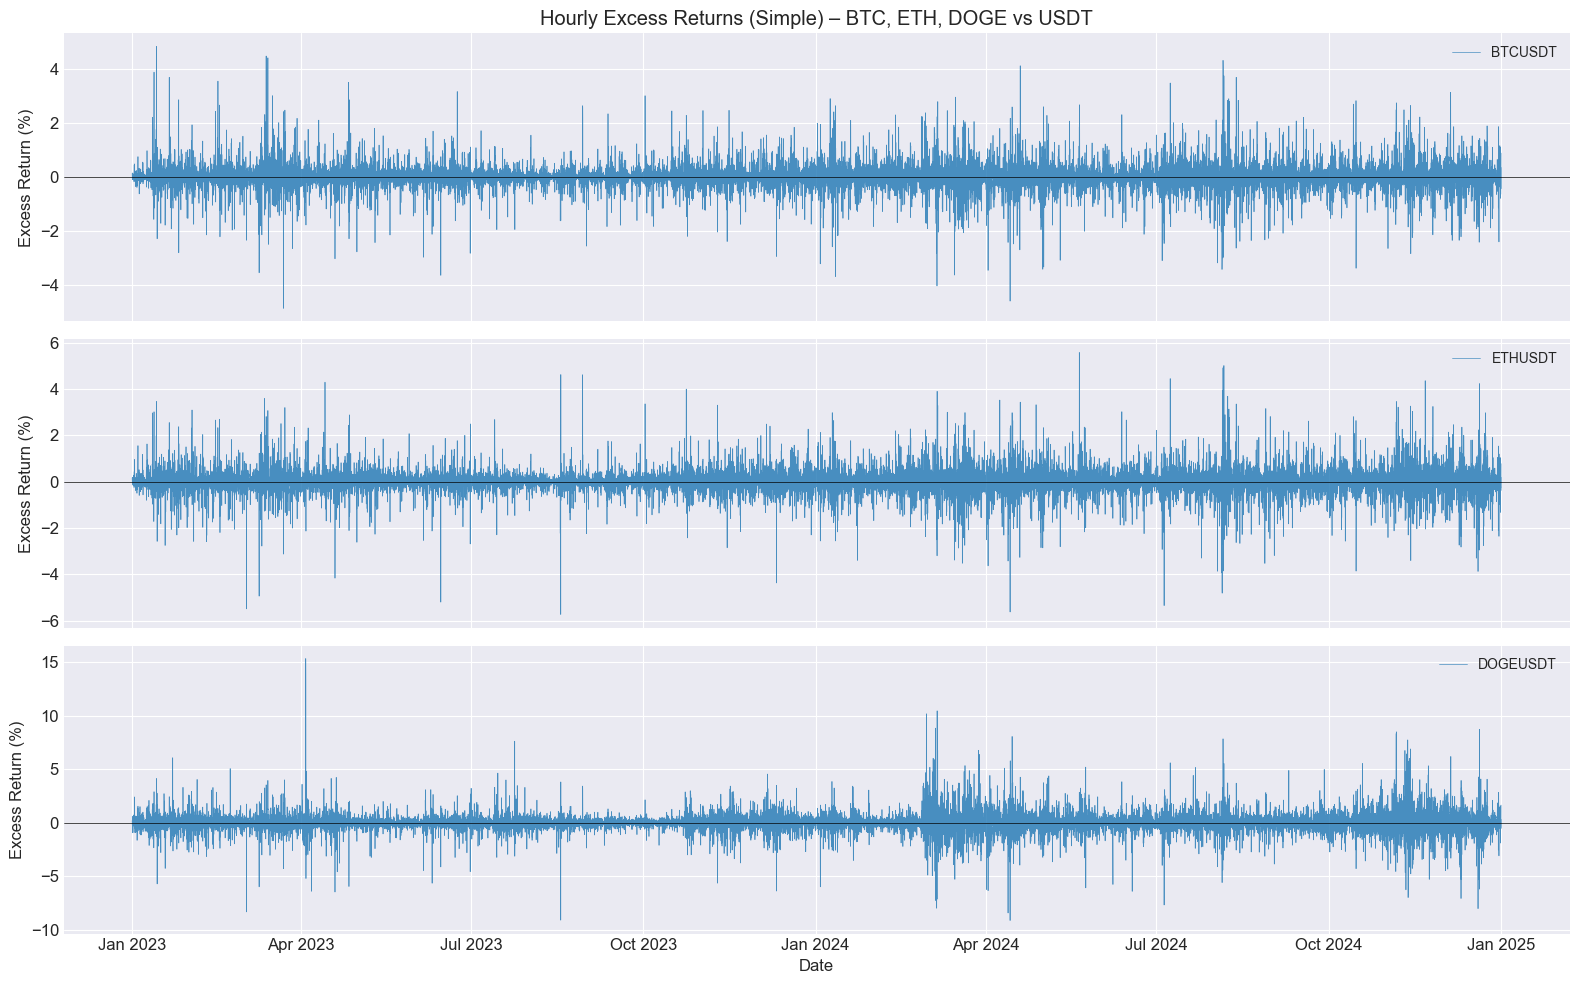

In [7]:
import os
os.makedirs('plots', exist_ok=True)
fig, axes = plt.subplots(len(SYMBOLS), 1, figsize=(16, 10), sharex=True)

for ax, sym in zip(axes, SYMBOLS):
    ax.plot(excess_returns.index, excess_returns[sym] * 100,
            linewidth=0.5, alpha=0.8, label=sym)
    ax.axhline(0, color='black', linewidth=0.5)
    ax.set_ylabel('Excess Return (%)')
    ax.legend(loc='upper right', fontsize=10)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

axes[0].set_title('Hourly Excess Returns (Simple) – BTC, ETH, DOGE vs USDT')
axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.savefig('plots/return_series.png', dpi=150)
plt.show()

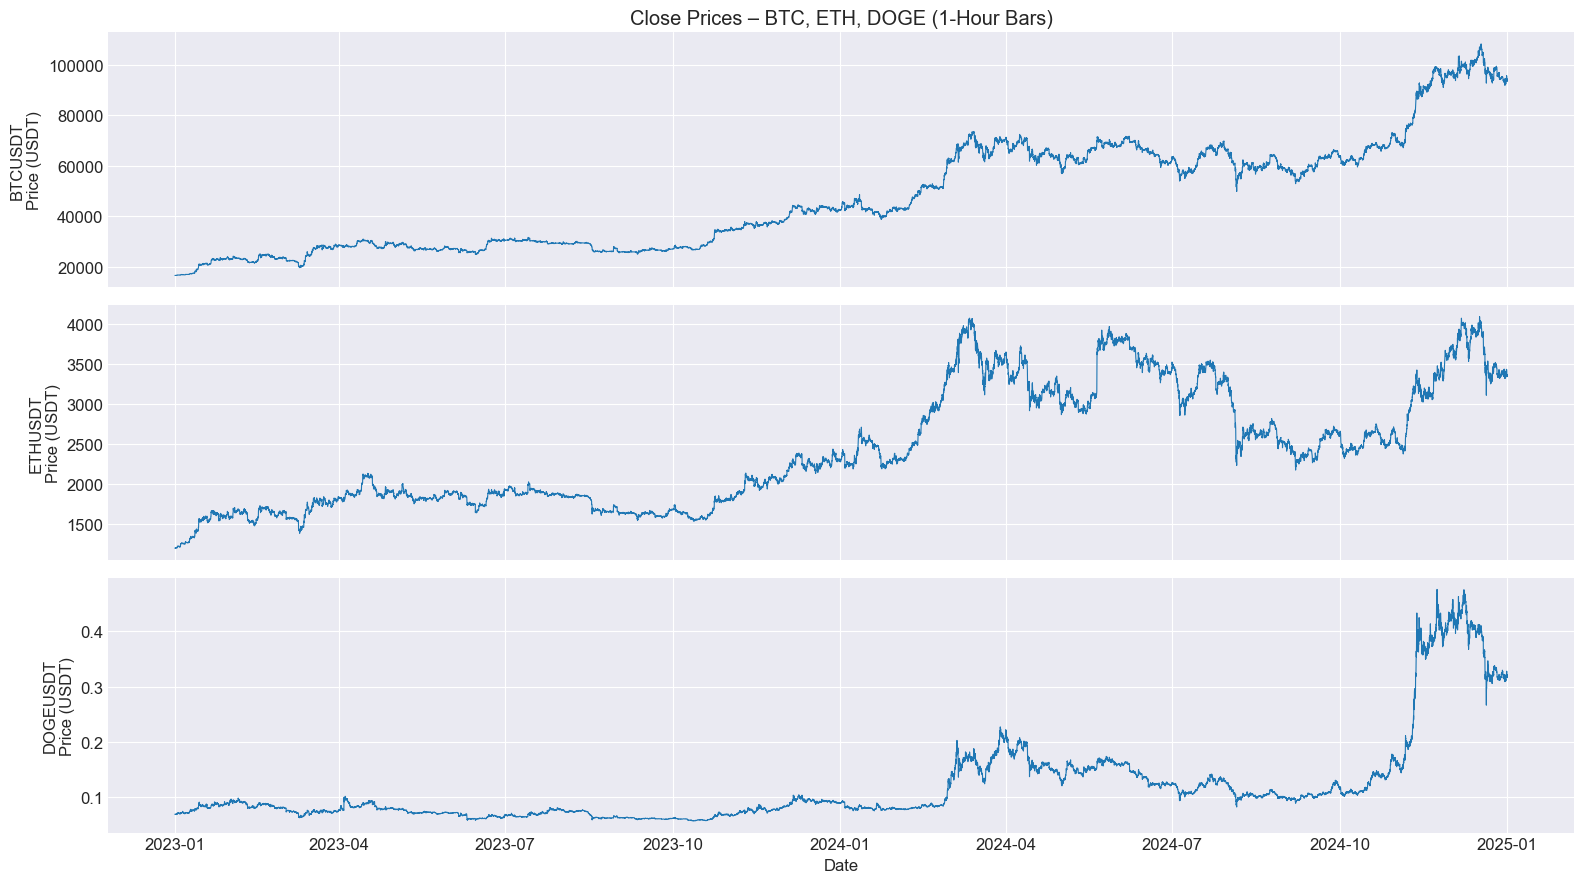

In [8]:
# Price series plot
fig, axes = plt.subplots(len(SYMBOLS), 1, figsize=(16, 9), sharex=True)
for ax, sym in zip(axes, SYMBOLS):
    ax.plot(prices.index, prices[sym], linewidth=0.8)
    ax.set_ylabel(f'{sym}\nPrice (USDT)')
axes[0].set_title('Close Prices – BTC, ETH, DOGE (1-Hour Bars)')
axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.show()

---
## 2. Trading Strategies 

Implement **two strategies**:
- **Strategy A:** Mean-Reversion (Bollinger Band z-score on a single asset)
- **Strategy B:** Cointegration / Pairs Trading (BTC–ETH spread)

In [9]:
# ── Constants ──────────────────────────────────────────────────────────────────
V0             = 10_000          # Starting capital USDT
MAX_GROSS_EXP  = 100_000         # 10× leverage cap

# Train / test split  (in-sample: first 70%, out-of-sample: last 30%)
n = len(prices)
split = int(n * 0.70)
IS  = prices.iloc[:split]   # in-sample
OOS = prices.iloc[split:]   # out-of-sample
print(f'In-sample:  {IS.index[0].date()} → {IS.index[-1].date()}  ({split} bars)')
print(f'OOS:        {OOS.index[0].date()} → {OOS.index[-1].date()}  ({n - split} bars)')

In-sample:  2023-01-01 → 2024-05-26  (12281 bars)
OOS:        2024-05-26 → 2025-01-01  (5264 bars)


### 2A. Strategy A – Mean-Reversion (Bollinger Band on BTC)

**Economic rationale:** Crypto prices exhibit short-term mean-reversion, driven by liquidity provision and over-reaction to noise. I exploit deviations of price from its rolling mean using a z-score signal.

**Signal:**
$$z_t = \frac{p_t - \mu_t}{\sigma_t}, \quad \mu_t = \text{EWM mean}, \quad \sigma_t = \text{EWM std}$$

**Entry/Exit:** Long if $z_t < -z_{\text{entry}}$, Short if $z_t > z_{\text{entry}}$, exit when $|z_t| < z_{\text{exit}}$.

In [10]:
# ── Parameter Selection (optimised on in-sample Sharpe) ───────────────────────
# We grid-search EWM span and entry threshold on IS data.

def zscore_signal(close: pd.Series, span: int) -> pd.Series:
    """Rolling EWM z-score."""
    mu  = close.ewm(span=span, adjust=False).mean()
    sig = close.ewm(span=span, adjust=False).std()
    return (close - mu) / sig.replace(0, np.nan)


def mean_rev_positions(close: pd.Series, span: int,
                        z_entry: float = 1.5, z_exit: float = 0.5) -> pd.Series:
    """
    Returns a signed position series {-1, 0, +1}.
    Position persists until exit threshold is crossed.
    """
    z = zscore_signal(close, span)
    pos = pd.Series(0.0, index=close.index)
    current = 0.0
    for t in range(1, len(z)):
        if pd.isna(z.iloc[t]):
            pos.iloc[t] = current
            continue
        if current == 0:
            if z.iloc[t] < -z_entry:
                current = 1.0     # go long (price below mean → mean-revert up)
            elif z.iloc[t] > z_entry:
                current = -1.0    # go short
        else:
            if abs(z.iloc[t]) < z_exit:
                current = 0.0     # close position
        pos.iloc[t] = current
    return pos


def is_sharpe(close: pd.Series, span: int, z_entry: float) -> float:
    pos  = mean_rev_positions(close, span, z_entry)
    ret  = close.pct_change()
    pnl  = (pos.shift(1) * ret).dropna()
    return pnl.mean() / pnl.std() * np.sqrt(24 * 365) if pnl.std() > 0 else -np.inf


# Grid search
best_sr, best_span, best_ze = -np.inf, 24, 1.5
for span in [12, 24, 48, 96, 168]:
    for ze in [1.0, 1.5, 2.0, 2.5]:
        sr = is_sharpe(IS['BTCUSDT'], span, ze)
        if sr > best_sr:
            best_sr, best_span, best_ze = sr, span, ze

print(f'Best IS Sharpe: {best_sr:.3f}  |  span={best_span}h  |  z_entry={best_ze}')
SPAN_A, Z_ENTRY_A, Z_EXIT_A = best_span, best_ze, 0.5

Best IS Sharpe: -0.705  |  span=48h  |  z_entry=1.0


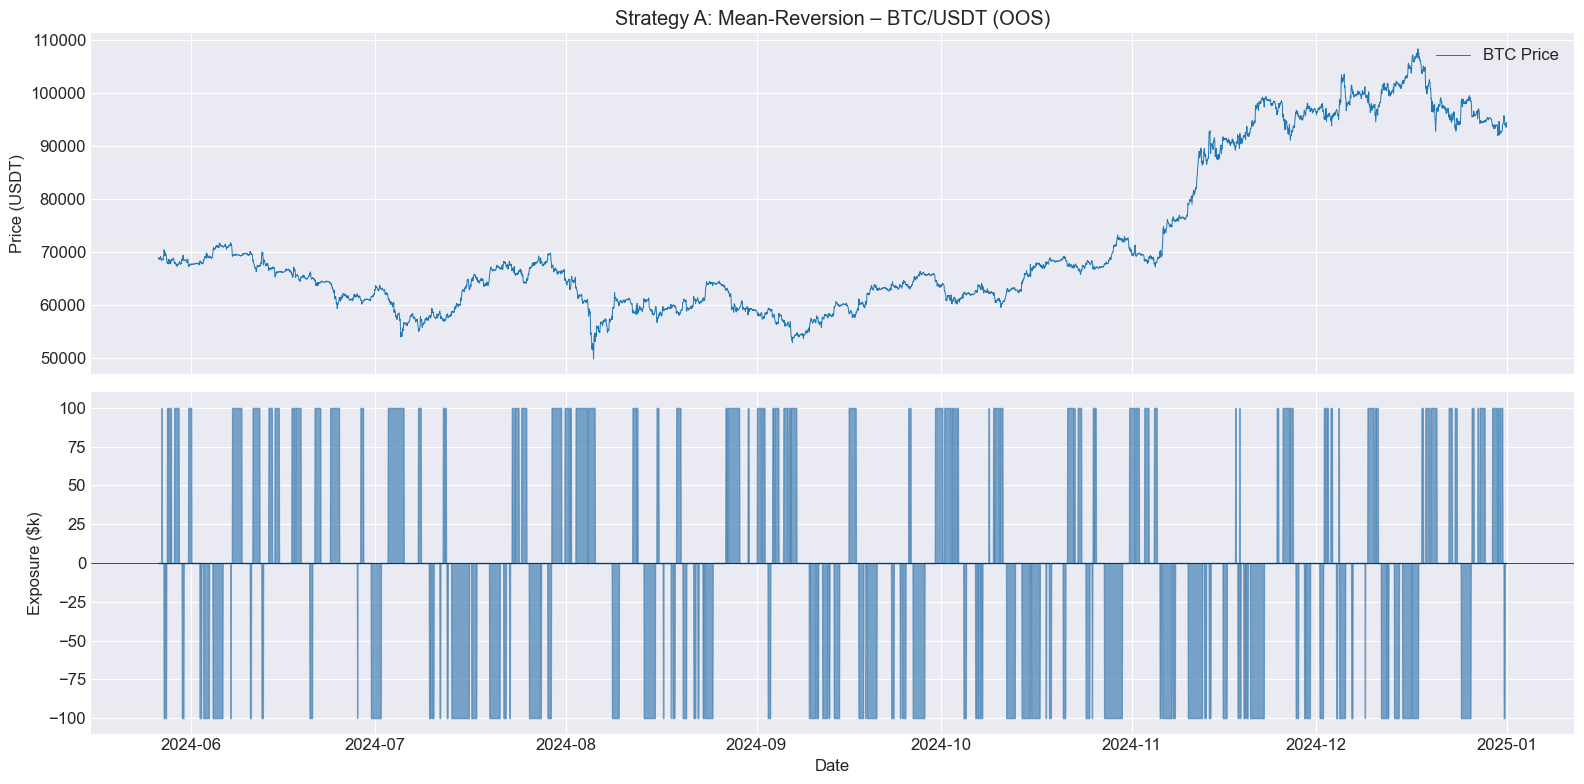

In [11]:
# ── Generate OOS signals & dollar exposures ────────────────────────────────────
# Use full price series (IS+OOS) so EWM is warm, then slice OOS.
pos_A_raw = mean_rev_positions(prices['BTCUSDT'], SPAN_A, Z_ENTRY_A, Z_EXIT_A)

# Scale so |θ| ≤ MAX_GROSS_EXP (single asset → all exposure on BTC)
theta_A = pos_A_raw * MAX_GROSS_EXP   # USDT dollar exposure
theta_A = theta_A.clip(-MAX_GROSS_EXP, MAX_GROSS_EXP)

# Visualise signal on OOS period
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
ax1.plot(prices['BTCUSDT'].iloc[split:], linewidth=0.7, label='BTC Price')
ax1.set_ylabel('Price (USDT)')
ax1.legend()
ax1.set_title('Strategy A: Mean-Reversion – BTC/USDT (OOS)')
ax2.fill_between(theta_A.iloc[split:].index, theta_A.iloc[split:] / 1000,
                 alpha=0.7, color='steelblue')
ax2.axhline(0, color='black', linewidth=0.5)
ax2.set_ylabel('Exposure (\$k)')
ax2.set_xlabel('Date')
plt.tight_layout()
plt.show()

### 2B. Strategy B – Cointegration / Pairs Trading (BTC–ETH)

**Economic rationale:** BTC and ETH share common crypto market risk factors; their log-price spread is stationary (cointegrated). Trade the spread when it deviates significantly from its long-run equilibrium.

**Model:**
$$\log(BTC_t) = \beta \cdot \log(ETH_t) + \alpha + \varepsilon_t, \quad \varepsilon_t \sim I(0)$$

**Signal:** $z_t = (\varepsilon_t - \mu_{\varepsilon}) / \sigma_{\varepsilon}$

In [12]:
# ── 1. Cointegration test on in-sample log prices ─────────────────────────────
log_btc = np.log(prices['BTCUSDT'])
log_eth = np.log(prices['ETHUSDT'])

score, pvalue, crit_vals = coint(log_btc.iloc[:split], log_eth.iloc[:split])
print(f'Engle-Granger cointegration p-value (IS): {pvalue:.4f}')
print(f'  → Reject H0 (no cointegration) at 5%: {pvalue < 0.05}')

# ── 2. OLS hedge ratio (estimated on IS) ──────────────────────────────────────
X_IS = sm.add_constant(log_eth.iloc[:split])
res  = OLS(log_btc.iloc[:split], X_IS).fit()
beta_hat = res.params['ETHUSDT']
alpha_hat = res.params['const']
print(f'\nHedge ratio β = {beta_hat:.4f},  α = {alpha_hat:.4f}')

# ── 3. Spread and z-score (full series, IS params) ────────────────────────────
spread = log_btc - (alpha_hat + beta_hat * log_eth)

# Rolling normalisation using IS stats
spread_mu  = spread.iloc[:split].mean()
spread_std = spread.iloc[:split].std()
z_spread   = (spread - spread_mu) / spread_std

# ADF test on IS spread residual
adf_stat, adf_p, *_ = adfuller(spread.iloc[:split].dropna())
print(f'\nADF test on IS spread: stat={adf_stat:.4f}, p={adf_p:.4f}')
print(f'  → Spread is stationary at 5%: {adf_p < 0.05}')

Engle-Granger cointegration p-value (IS): 0.2184
  → Reject H0 (no cointegration) at 5%: False

Hedge ratio β = 1.3373,  α = 0.2418

ADF test on IS spread: stat=-2.6488, p=0.0833
  → Spread is stationary at 5%: False


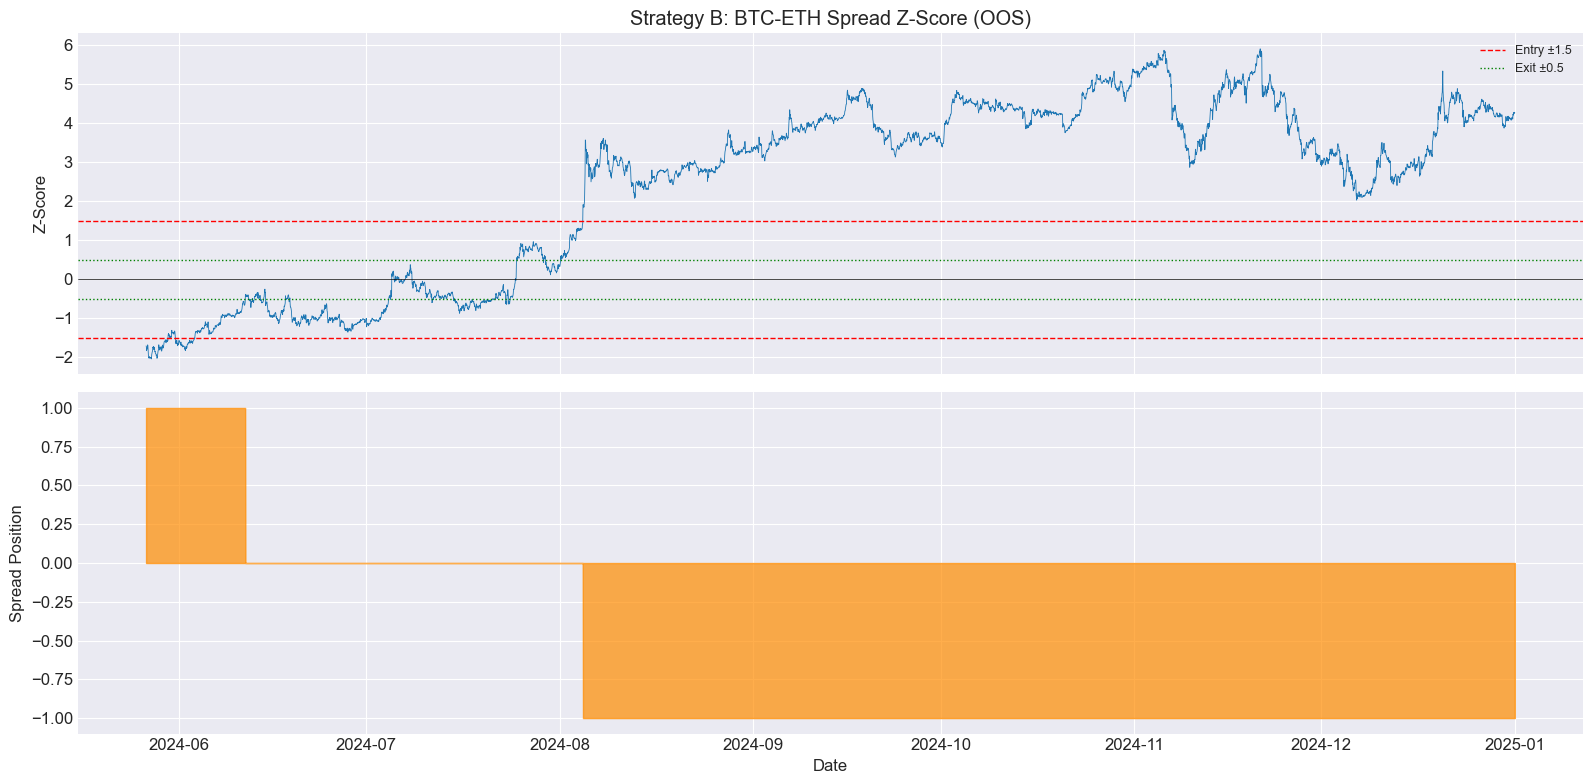

In [13]:
# ── 4. Signal generation and exposure (OOS) ───────────────────────────────────
Z_ENTRY_B = 1.5
Z_EXIT_B  = 0.5

def pairs_positions(z: pd.Series, z_entry: float, z_exit: float) -> pd.Series:
    """Position on the spread: +1 = long spread (long BTC, short ETH), -1 = vice versa."""
    pos = pd.Series(0.0, index=z.index)
    current = 0.0
    for t in range(1, len(z)):
        if pd.isna(z.iloc[t]):
            pos.iloc[t] = current
            continue
        if current == 0:
            if z.iloc[t] > z_entry:
                current = -1.0    # spread too wide → short it
            elif z.iloc[t] < -z_entry:
                current = 1.0     # spread too narrow → long it
        else:
            if abs(z.iloc[t]) < z_exit:
                current = 0.0
        pos.iloc[t] = current
    return pos


pos_spread = pairs_positions(z_spread, Z_ENTRY_B, Z_EXIT_B)

# Dollar exposures: each leg gets half the gross cap → total gross = MAX_GROSS_EXP
LEG_SIZE = MAX_GROSS_EXP / 2
theta_B_btc  =  pos_spread * LEG_SIZE    # BTC leg
theta_B_eth  = -pos_spread * LEG_SIZE * beta_hat  # ETH hedge leg

# Plot OOS spread
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
ax1.plot(z_spread.iloc[split:], linewidth=0.6)
ax1.axhline( Z_ENTRY_B, color='red',   linestyle='--', linewidth=1, label=f'Entry ±{Z_ENTRY_B}')
ax1.axhline(-Z_ENTRY_B, color='red',   linestyle='--', linewidth=1)
ax1.axhline( Z_EXIT_B,  color='green', linestyle=':',  linewidth=1, label=f'Exit ±{Z_EXIT_B}')
ax1.axhline(-Z_EXIT_B,  color='green', linestyle=':',  linewidth=1)
ax1.axhline(0, color='black', linewidth=0.5)
ax1.set_title('Strategy B: BTC-ETH Spread Z-Score (OOS)')
ax1.set_ylabel('Z-Score')
ax1.legend(fontsize=9)
ax2.fill_between(pos_spread.iloc[split:].index, pos_spread.iloc[split:],
                 alpha=0.7, color='darkorange')
ax2.set_ylabel('Spread Position')
ax2.set_xlabel('Date')
plt.tight_layout()
plt.show()

### 2C. Position Sizing – Mean-Variance Optimisation (MVO)

For the combined portfolio (both strategies active simultaneously) I use MVO to allocate the gross exposure budget across the signal vectors, subject to the $100k gross constraint.

In [14]:
def mvo_weights(mu_vec: np.ndarray, cov_mat: np.ndarray,
                risk_aversion: float = 2.0) -> np.ndarray:
    """
    Mean-variance optimal weights (unconstrained analytical solution):
      w* = (1/γ) Σ^{-1} μ
    Then normalise so sum(|w|) = 1.
    """
    try:
        cov_inv = np.linalg.pinv(cov_mat)
    except np.linalg.LinAlgError:
        return np.ones(len(mu_vec)) / len(mu_vec)
    w = (1.0 / risk_aversion) * cov_inv @ mu_vec
    norm = np.sum(np.abs(w))
    return w / norm if norm > 1e-10 else np.zeros(len(mu_vec))


# Rolling MVO: estimate expected returns and covariance over past 30-day window
ROLL_WINDOW = 24 * 30   # 720 hours
RET = returns[SYMBOLS]

mvo_w = pd.DataFrame(index=prices.index, columns=SYMBOLS, dtype=float).fillna(0.0)

for t in range(ROLL_WINDOW, len(prices)):
    window_ret = RET.iloc[t - ROLL_WINDOW:t]
    mu   = window_ret.mean().values
    cov  = window_ret.cov().values
    w    = mvo_weights(mu, cov)
    mvo_w.iloc[t] = w

print('MVO weight sample (last row):')
print(mvo_w.iloc[-1])

MVO weight sample (last row):
BTCUSDT     0.499867
ETHUSDT     0.106940
DOGEUSDT   -0.393193
Name: 2025-01-01 00:00:00+00:00, dtype: float64


---
## 3. Transaction Costs – Roll Model [10 Points]

The **Roll (1984) model** estimates the bid-ask spread $s$ from the serial covariance of price changes:
$$s = 2\sqrt{-\text{Cov}(\Delta p_t, \Delta p_{t-1})}$$

If the covariance is positive (due to microstructure noise), we set $s = 0$.

In [15]:
def roll_spread(close: pd.Series, window: int = 24 * 30) -> pd.Series:
    """
    Rolling Roll (1984) half-spread estimate.
    Returns the full spread as a fraction of price (decimal).
    """
    dp  = close.diff()
    cov = dp.rolling(window).cov(dp.shift(1))
    s   = 2 * np.sqrt(np.maximum(-cov, 0))
    # Express as a fraction of price
    return (s / close).fillna(0)


roll_s = {sym: roll_spread(prices[sym]) for sym in SYMBOLS}

print('Mean Roll half-spread estimates (full period):')
for sym in SYMBOLS:
    mean_s = roll_s[sym].mean() * 1e4
    print(f'  {sym}: {mean_s:.2f} bps')

# Use the OOS-period mean as our slippage estimate
SLIPPAGE = {sym: roll_s[sym].iloc[split:].mean() for sym in SYMBOLS}
print('\nOOS slippage estimates (used in PnL):')
for sym, s in SLIPPAGE.items():
    print(f'  {sym}: {s*1e4:.2f} bps  ({s:.6f})')

Mean Roll half-spread estimates (full period):
  BTCUSDT: 11.34 bps
  ETHUSDT: 14.87 bps
  DOGEUSDT: 23.77 bps

OOS slippage estimates (used in PnL):
  BTCUSDT: 14.44 bps  (0.001444)
  ETHUSDT: 20.78 bps  (0.002078)
  DOGEUSDT: 32.13 bps  (0.003213)


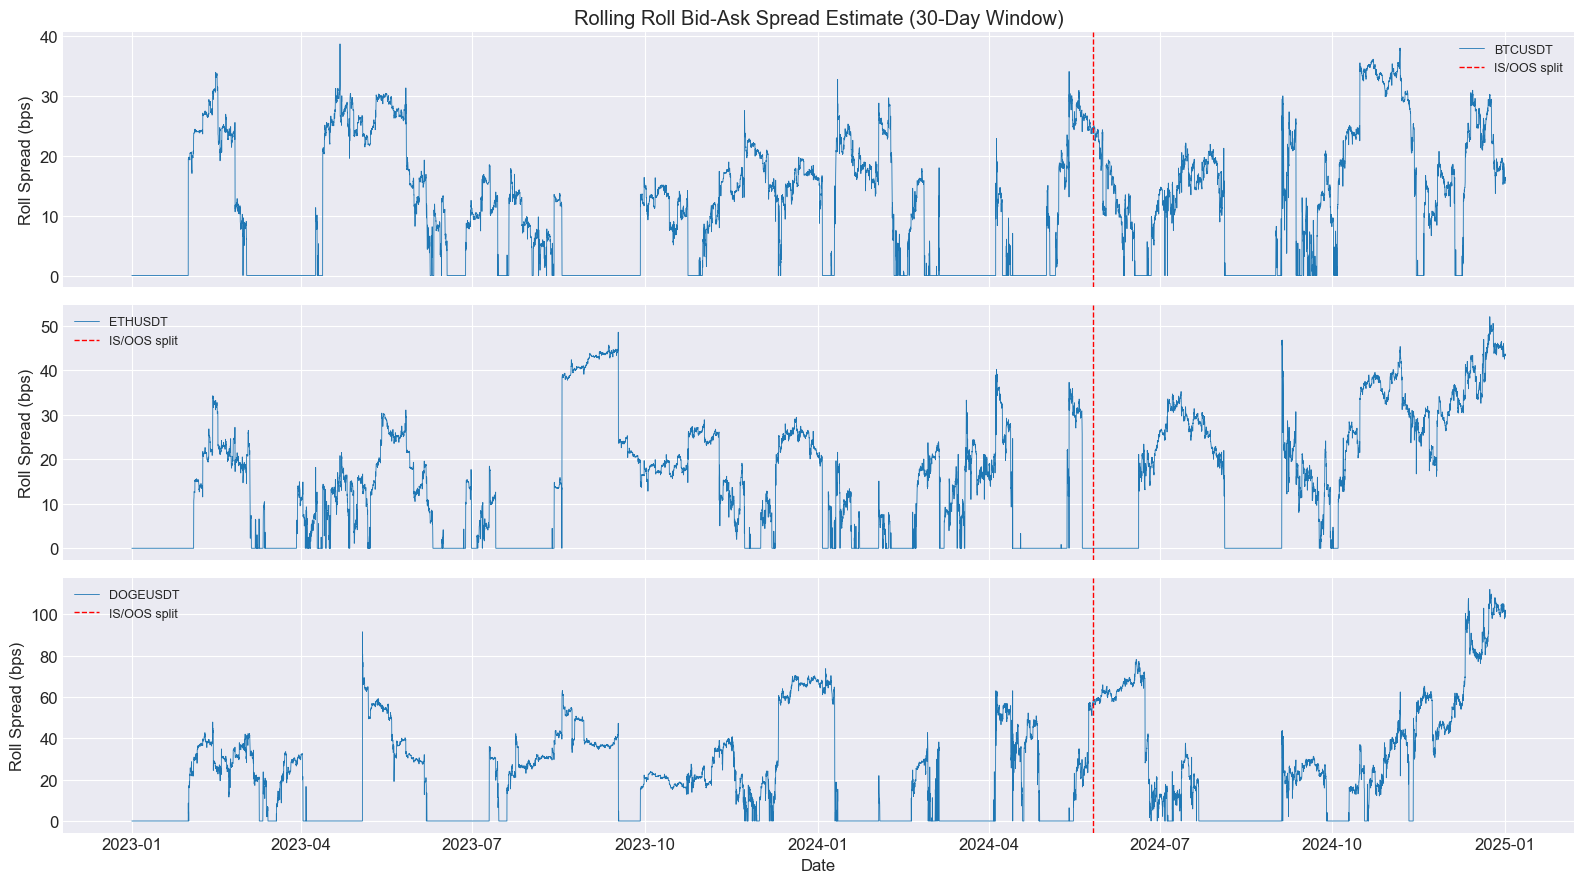

In [16]:
# ── Plot rolling spread ────────────────────────────────────────────────────────
fig, axes = plt.subplots(len(SYMBOLS), 1, figsize=(16, 9), sharex=True)
for ax, sym in zip(axes, SYMBOLS):
    ax.plot(roll_s[sym] * 1e4, linewidth=0.6, label=sym)
    ax.axvline(prices.index[split], color='red', linestyle='--',
               linewidth=1, label='IS/OOS split')
    ax.set_ylabel('Roll Spread (bps)')
    ax.legend(fontsize=9)
axes[0].set_title('Rolling Roll Bid-Ask Spread Estimate (30-Day Window)')
axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.show()

### 3.1 Sensitivity Analysis – Slippage vs Sharpe Ratio

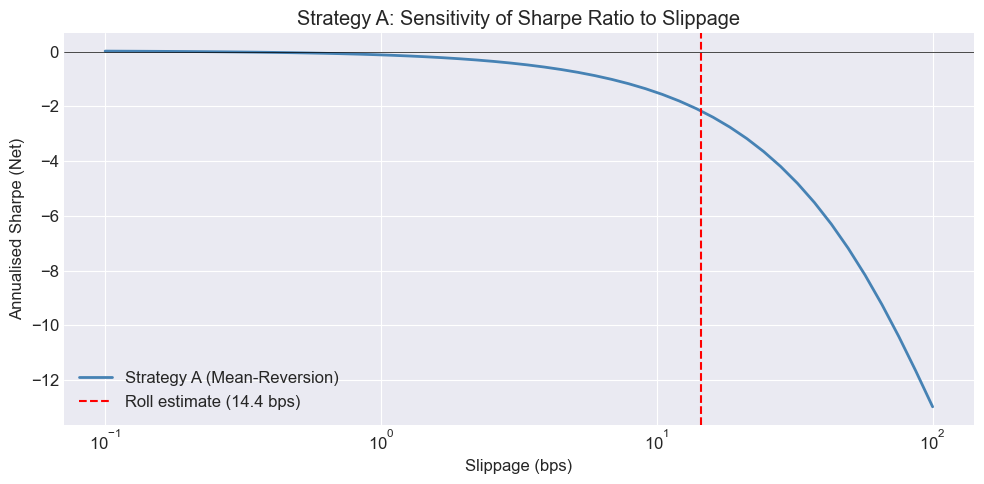

Break-even slippage for Strategy A: ~0.2 bps


In [17]:
def compute_net_sharpe(theta: pd.Series, close: pd.Series,
                        slippage: float) -> float:
    """Compute annualised Sharpe (net of costs) for a given slippage."""
    ret   = close.pct_change()
    pnl   = theta.shift(1) * ret
    trade = theta.diff().abs()
    cost  = slippage * trade.shift(1).fillna(0)
    net   = (pnl - cost).dropna()
    return net.mean() / net.std() * np.sqrt(24 * 365) if net.std() > 0 else np.nan


slippage_grid = np.logspace(-5, -2, 50)  # 0.001 bps → 100 bps
sh_A = [compute_net_sharpe(theta_A.iloc[split:],
                            prices['BTCUSDT'].iloc[split:], s)
        for s in slippage_grid]

fig, ax = plt.subplots(figsize=(10, 5))
ax.semilogx(slippage_grid * 1e4, sh_A, linewidth=2, color='steelblue',
            label='Strategy A (Mean-Reversion)')
ax.axvline(SLIPPAGE['BTCUSDT'] * 1e4, color='red', linestyle='--',
           label=f'Roll estimate ({SLIPPAGE["BTCUSDT"]*1e4:.1f} bps)')
ax.axhline(0, color='black', linewidth=0.5)
ax.set_xlabel('Slippage (bps)')
ax.set_ylabel('Annualised Sharpe (Net)')
ax.set_title('Strategy A: Sensitivity of Sharpe Ratio to Slippage')
ax.legend()
plt.tight_layout()
plt.show()

# Slippage at which Sharpe = 0 (break-even)
from numpy import interp
be_bps = interp(0, sh_A[::-1], slippage_grid[::-1] * 1e4)
print(f'Break-even slippage for Strategy A: ~{be_bps:.1f} bps')

---
## 4. Performance Analysis [10 Points]

$$\Delta V_t = \sum_{i=1}^{k} \theta_t^i r_t^i - \text{Cost}_t$$
$$\text{Cost}_t = s \times \sum_i |\theta_t^i - \theta_{t-1}^i (1 + r_{t-1}^i)|$$

In [18]:
def compute_pnl(thetas: dict, prices: pd.DataFrame,
                slippages: dict, V0: float = 10_000.0) -> pd.DataFrame:
    """
    Compute PnL series for a portfolio of strategies.

    Parameters
    ----------
    thetas     : {symbol: pd.Series of USDT dollar exposures}
    prices     : OHLCV close DataFrame
    slippages  : {symbol: float} slippage per unit traded
    V0         : starting capital

    Returns
    -------
    DataFrame with columns: gross_pnl, cost, net_pnl, portfolio_value, cash
    """
    idx    = prices.index
    rets   = prices.pct_change()
    result = pd.DataFrame(index=idx)

    gross_pnl = pd.Series(0.0, index=idx)
    total_cost = pd.Series(0.0, index=idx)

    for sym, theta in thetas.items():
        r   = rets[sym]
        s   = slippages.get(sym, 0.0)

        # Gross PnL from position
        gross_pnl += theta.shift(1) * r

        # Cost: |θ_t - θ_{t-1} * (1 + r_{t-1})|
        theta_drift = theta.shift(1) * (1 + r.shift(1))
        trade_size  = (theta - theta_drift.fillna(0)).abs()
        total_cost  += s * trade_size.shift(1).fillna(0)

    net_pnl = gross_pnl - total_cost

    # Portfolio value (unallocated capital sits in USDT cash)
    result['gross_pnl']       = gross_pnl
    result['cost']            = total_cost
    result['net_pnl']         = net_pnl
    result['cumulative_net']  = net_pnl.cumsum() + V0
    result['cumulative_gross']= gross_pnl.cumsum() + V0
    return result


# ── Strategy A (OOS) ──────────────────────────────────────────────────────────
thetas_A = {'BTCUSDT': theta_A.iloc[split:]}
pnl_A    = compute_pnl(thetas_A, prices.iloc[split:],
                        {'BTCUSDT': SLIPPAGE['BTCUSDT']}, V0)

# ── Strategy B (OOS) ──────────────────────────────────────────────────────────
thetas_B = {'BTCUSDT': theta_B_btc.iloc[split:],
            'ETHUSDT': theta_B_eth.iloc[split:]}
pnl_B    = compute_pnl(thetas_B, prices.iloc[split:],
                        {'BTCUSDT': SLIPPAGE['BTCUSDT'],
                         'ETHUSDT': SLIPPAGE['ETHUSDT']}, V0)

print('PnL computation complete.')

PnL computation complete.


### 4.1 Performance Ratios

In [19]:
def sharpe(pnl_series: pd.Series, ann_factor: float = 24 * 365) -> float:
    """Annualised Sharpe ratio."""
    return pnl_series.mean() / pnl_series.std() * np.sqrt(ann_factor)


def sortino(pnl_series: pd.Series, ann_factor: float = 24 * 365) -> float:
    """Annualised Sortino ratio."""
    downside = pnl_series[pnl_series < 0].std()
    return pnl_series.mean() / downside * np.sqrt(ann_factor) if downside > 0 else np.nan


def max_drawdown(cum_pnl: pd.Series) -> float:
    """Maximum drawdown (as a positive fraction of peak)."""
    roll_max = cum_pnl.cummax()
    dd = (cum_pnl - roll_max) / roll_max
    return dd.min()


def calmar(pnl_series: pd.Series, cum_pnl: pd.Series,
           ann_factor: float = 24 * 365) -> float:
    """Annualised Calmar ratio = annualised return / |max drawdown|."""
    ann_ret = pnl_series.mean() * ann_factor
    mdd = abs(max_drawdown(cum_pnl))
    return ann_ret / mdd if mdd > 0 else np.nan


def turnover(thetas: dict, prices: pd.DataFrame) -> float:
    """Total two-way turnover (sum of |Δθ| / V0)."""
    total = 0.0
    for sym, th in thetas.items():
        total += th.diff().abs().sum()
    return total / V0


def avg_holding(pos: pd.Series) -> float:
    """Average holding duration in bars."""
    in_pos = (pos != 0).astype(int)
    changes = in_pos.diff().fillna(0)
    entries = (changes > 0).sum()
    total_bars = in_pos.sum()
    return total_bars / entries if entries > 0 else np.nan


metrics = {}
for name, pnl_df, thetas_dict, pos_series in [
        ('Strategy A (Mean-Rev)', pnl_A, thetas_A, pos_A_raw.iloc[split:]),
        ('Strategy B (Pairs)',    pnl_B, thetas_B, pos_spread.iloc[split:]),
]:
    net = pnl_df['net_pnl'].dropna()
    gross = pnl_df['gross_pnl'].dropna()
    cum_net = pnl_df['cumulative_net'].dropna()

    final_val = cum_net.iloc[-1]
    total_pnl = final_val - V0
    pct_return = total_pnl / V0 * 100

    metrics[name] = {
        'Sharpe (Gross)':    sharpe(gross),
        'Sharpe (Net)':      sharpe(net),
        'Sortino (Net)':     sortino(net),
        'Max Drawdown':      max_drawdown(cum_net),
        'Calmar (Net)':      calmar(net, cum_net),
        'Total Turnover':    turnover(thetas_dict, prices.iloc[split:]),
        'Avg Holding (h)':   avg_holding(pos_series),
        'Total PnL ($)':     total_pnl,
        'Return (%)':        pct_return,
        'Total Costs ($)':   pnl_df['cost'].sum(),
    }

metrics_df = pd.DataFrame(metrics).T
print('\n=== Performance Summary (OOS) ===')
print(metrics_df.round(3).to_string())


=== Performance Summary (OOS) ===
                       Sharpe (Gross)  Sharpe (Net)  Sortino (Net)  Max Drawdown  Calmar (Net)  Total Turnover  Avg Holding (h)  Total PnL ($)  Return (%)  Total Costs ($)
Strategy A (Mean-Rev)           0.037        -2.223         -2.080        -5.298    -16160.102        3520.000           14.642     -51438.417    -514.384        52297.707
Strategy B (Pairs)             -0.088        -0.397         -0.487        -1.177     -7987.783          23.373         3966.000      -5649.566     -56.496         4391.436


### 4.2 Cumulative PnL Plot

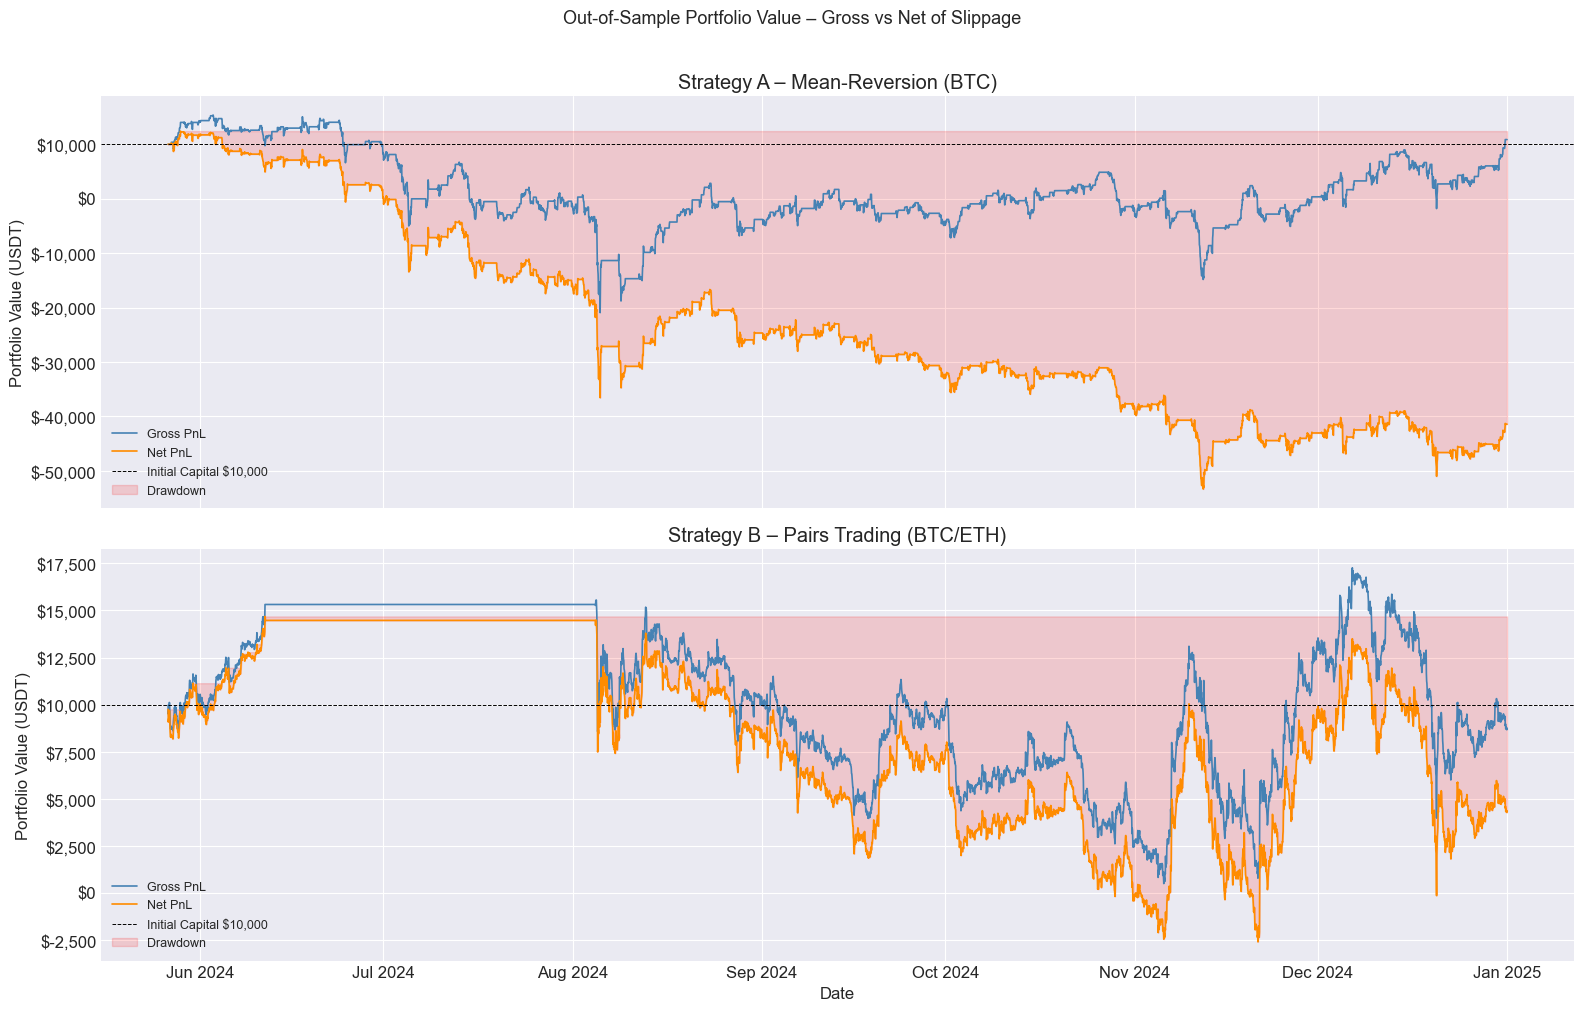

In [20]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

for ax, (label, pnl_df) in zip(axes, [
        ('Strategy A – Mean-Reversion (BTC)', pnl_A),
        ('Strategy B – Pairs Trading (BTC/ETH)', pnl_B)
]):
    ax.plot(pnl_df['cumulative_gross'], linewidth=1.2,
            label='Gross PnL', color='steelblue')
    ax.plot(pnl_df['cumulative_net'], linewidth=1.2,
            label='Net PnL', color='darkorange')
    ax.axhline(V0, color='black', linewidth=0.7, linestyle='--', label=f'Initial Capital ${V0:,}')

    # Drawdown shading
    cum = pnl_df['cumulative_net'].dropna()
    roll_max = cum.cummax()
    ax.fill_between(cum.index, cum, roll_max, alpha=0.15, color='red', label='Drawdown')

    ax.set_title(label)
    ax.set_ylabel('Portfolio Value (USDT)')
    ax.legend(fontsize=9)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

axes[-1].set_xlabel('Date')
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.suptitle('Out-of-Sample Portfolio Value – Gross vs Net of Slippage', y=1.01, fontsize=13)
plt.tight_layout()
plt.savefig('plots/pnl_curves.png', dpi=150)
plt.show()

### 4.3 Drawdown Profiles

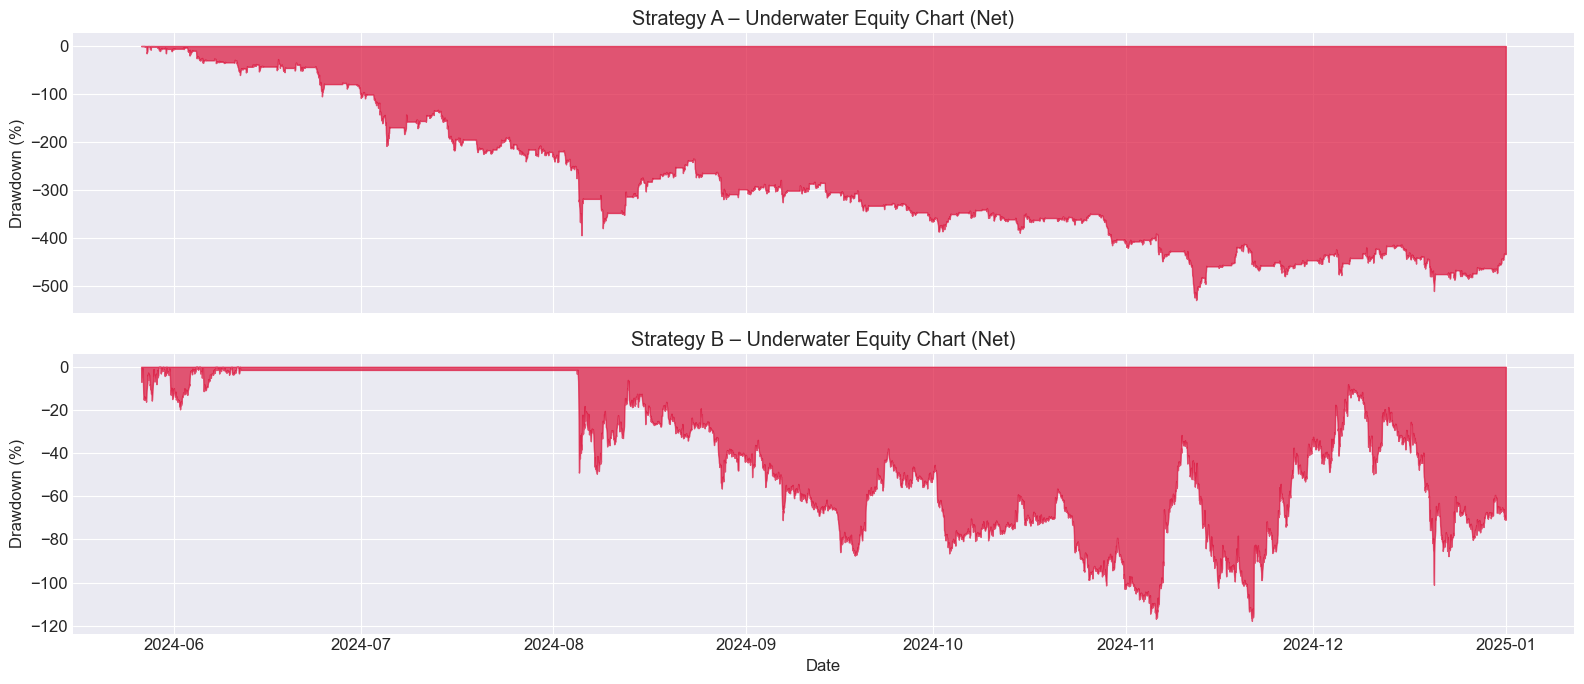

In [21]:
fig, axes = plt.subplots(2, 1, figsize=(16, 7), sharex=True)

for ax, (label, pnl_df) in zip(axes, [
        ('Strategy A', pnl_A), ('Strategy B', pnl_B)
]):
    cum = pnl_df['cumulative_net'].dropna()
    dd  = (cum - cum.cummax()) / cum.cummax() * 100
    ax.fill_between(dd.index, dd, 0, alpha=0.7, color='crimson')
    ax.set_ylabel('Drawdown (%)')
    ax.set_title(f'{label} – Underwater Equity Chart (Net)')

axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.show()

### 4.4 Reinvestment Logic

**Design decision:** I maintain a **fixed gross exposure cap** of $100k at each rebalance step rather than scaling positions with accumulated profits. Rationale:
- Prevents convex position growth that would amplify drawdowns after a winning run.
- Keeps risk metrics (Sharpe, Sortino) comparable across time.
- Capital in excess of required margin is held in USDT cash, earning the stablecoin money-market rate.

An alternative is to **reinvest profits** (Kelly-style fractional sizing), which we leave for the Next Steps section.

---
## 5. Next Steps [10 Points]

### 5.1 Performance Across Time Horizons

In [22]:
# Aggregate returns at different horizons and compare Sharpe
horizons = {'1h': 1, '4h': 4, '8h': 8, '24h': 24}
results_by_horizon = {}

for label, h in horizons.items():
    # Resample exposures and prices to h-hour bars
    p_rs   = prices['BTCUSDT'].resample(f'{h}h').last().dropna()
    th_rs  = theta_A.resample(f'{h}h').last().reindex(p_rs.index).fillna(0)
    ret_rs = p_rs.pct_change()
    pnl_rs = (th_rs.shift(1) * ret_rs).dropna()
    ann    = (365 * 24) / h
    sr     = pnl_rs.mean() / pnl_rs.std() * np.sqrt(ann) if pnl_rs.std() > 0 else np.nan
    results_by_horizon[label] = {'Sharpe': sr, 'bars': len(pnl_rs)}

hz_df = pd.DataFrame(results_by_horizon).T
print('Strategy A Sharpe by resampled horizon:')
print(hz_df.round(3))

Strategy A Sharpe by resampled horizon:
     Sharpe     bars
1h   -0.464  17544.0
4h   -0.498   4386.0
8h   -1.020   2193.0
24h   0.257    731.0


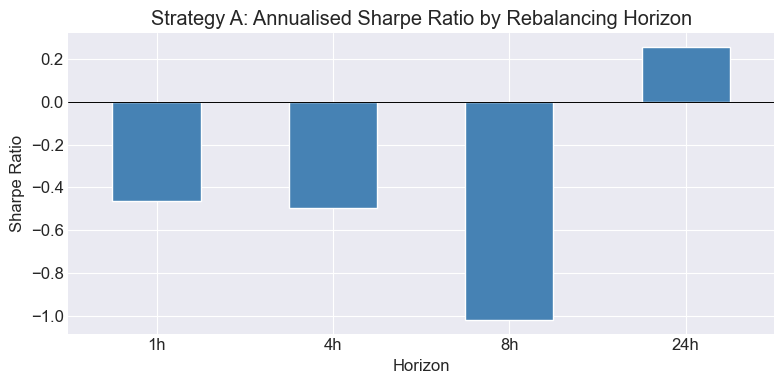

In [23]:
# Bar chart
fig, ax = plt.subplots(figsize=(8, 4))
hz_df['Sharpe'].plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.axhline(0, color='black', linewidth=0.7)
ax.set_title('Strategy A: Annualised Sharpe Ratio by Rebalancing Horizon')
ax.set_ylabel('Sharpe Ratio')
ax.set_xlabel('Horizon')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 5.2 Strategy Improvement Ideas

The following cell documents the key improvements that could be implemented as extensions:

In [24]:
next_steps = """
NEXT STEPS – STRATEGY IMPROVEMENTS
====================================

1. REGIME DETECTION
   - Use a Hidden Markov Model (HMM) or volatility regime classifier
     (low/medium/high vol) to activate mean-reversion only in mean-reverting
     regimes and trend-following in trending regimes.
   - Expected improvement: avoid large drawdowns during momentum cycles.

2. DYNAMIC HEDGE RATIO (Kalman Filter)
   - Replace static OLS hedge ratio β in Strategy B with a Kalman filter
     that tracks time-varying cointegration.
   - Avoids "cointegration breakdown" events that cause pairs strategies to fail.

3. TRANSACTION COST AWARENESS IN POSITION SIZING
   - Replace MVO with a cost-penalised objective:
       max_θ  μ'θ - (γ/2)θ'Σθ - λ||θ - θ_{prev}||₁
   - Reduces unnecessary rebalancing and improves net Sharpe.

4. KELLY FRACTIONAL POSITION SIZING
   - Size positions as a fraction of the Kelly-optimal bet to balance
     growth and drawdown risk.

5. ADDITIONAL FEATURES / SIGNALS
   - Order book imbalance (requires Level 2 data)
   - Funding rate from Binance perpetuals as a sentiment signal
   - On-chain metrics (active addresses, exchange flows)
   - Cross-exchange arbitrage signals

6. LIVE TRADING CONSIDERATIONS
   - Latency: API round-trip on Binance ~10–50ms; need co-location for HF.
   - Slippage: Roll model under-estimates market impact for large orders;
     use Almgren-Chriss or Kyle lambda for execution cost modelling.
   - Risk limits: Hard stop-loss per strategy (e.g., -5% of V0 per day).
   - Operational risk: Handle Binance API rate limits, websocket reconnects.

7. EXPECTED PERFORMANCE CONDITIONS
   - Strategy A performs well in: low-trend, range-bound markets with
     high liquidity (e.g., sideways BTC in Q2 2023).
   - Strategy A performs poorly in: strong trending markets (bull/bear run).
   - Strategy B (pairs) performs well when: BTC/ETH correlation is stable.
   - Strategy B performs poorly when: idiosyncratic ETH news (e.g., upgrades)
     breaks the spread.
"""
print(next_steps)


NEXT STEPS – STRATEGY IMPROVEMENTS

1. REGIME DETECTION
   - Use a Hidden Markov Model (HMM) or volatility regime classifier
     (low/medium/high vol) to activate mean-reversion only in mean-reverting
     regimes and trend-following in trending regimes.
   - Expected improvement: avoid large drawdowns during momentum cycles.

2. DYNAMIC HEDGE RATIO (Kalman Filter)
   - Replace static OLS hedge ratio β in Strategy B with a Kalman filter
     that tracks time-varying cointegration.
   - Avoids "cointegration breakdown" events that cause pairs strategies to fail.

3. TRANSACTION COST AWARENESS IN POSITION SIZING
   - Replace MVO with a cost-penalised objective:
       max_θ  μ'θ - (γ/2)θ'Σθ - λ||θ - θ_{prev}||₁
   - Reduces unnecessary rebalancing and improves net Sharpe.

4. KELLY FRACTIONAL POSITION SIZING
   - Size positions as a fraction of the Kelly-optimal bet to balance
     growth and drawdown risk.

5. ADDITIONAL FEATURES / SIGNALS
   - Order book imbalance (requires Level 2 d

### 5.3 Proposed Improvement: Regime-Filtered Mean-Reversion

In [25]:
# Simple regime filter: only trade mean-reversion when realised vol is BELOW median
# (low-vol environments are more likely to be mean-reverting)

ROLL_VOL_WINDOW = 24 * 7  # 1-week rolling vol
realised_vol = returns['BTCUSDT'].rolling(ROLL_VOL_WINDOW).std() * np.sqrt(24 * 365)
vol_median   = realised_vol.iloc[:split].median()

# Regime: 0 = high-vol (avoid mean-reversion), 1 = low-vol (trade)
low_vol_regime = (realised_vol < vol_median).astype(float)

# Apply regime filter to Strategy A
theta_A_filtered = theta_A * low_vol_regime

# Evaluate
thetas_A_filt = {'BTCUSDT': theta_A_filtered.iloc[split:]}
pnl_A_filt    = compute_pnl(thetas_A_filt, prices.iloc[split:],
                              {'BTCUSDT': SLIPPAGE['BTCUSDT']}, V0)

net_filt = pnl_A_filt['net_pnl'].dropna()
net_base = pnl_A['net_pnl'].dropna()

print('Strategy A – Baseline vs Regime-Filtered (OOS):')
print(f'  Baseline  Sharpe: {sharpe(net_base):.3f}')
print(f'  Filtered  Sharpe: {sharpe(net_filt):.3f}')
print(f'  Baseline Max DD:  {max_drawdown(pnl_A["cumulative_net"].dropna()):.3%}')
print(f'  Filtered Max DD:  {max_drawdown(pnl_A_filt["cumulative_net"].dropna()):.3%}')

Strategy A – Baseline vs Regime-Filtered (OOS):
  Baseline  Sharpe: -2.223
  Filtered  Sharpe: -2.419
  Baseline Max DD:  -529.803%
  Filtered Max DD:  -228.570%


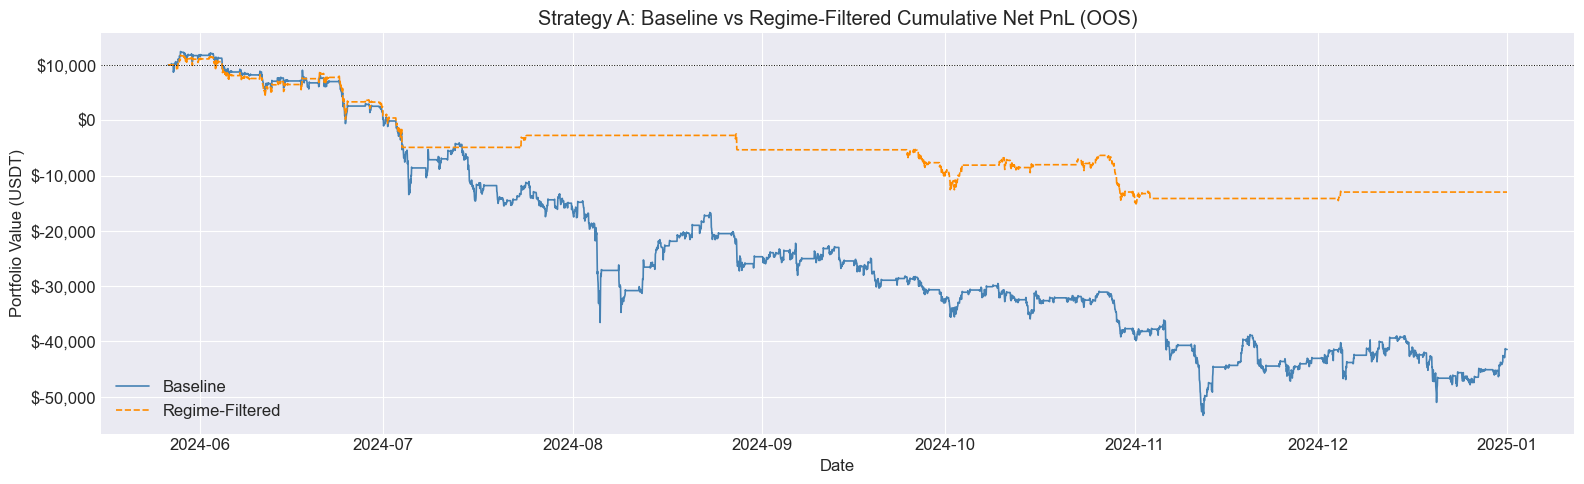

In [26]:
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(pnl_A['cumulative_net'], label='Baseline', linewidth=1.2, color='steelblue')
ax.plot(pnl_A_filt['cumulative_net'], label='Regime-Filtered', linewidth=1.2,
        color='darkorange', linestyle='--')
ax.axhline(V0, color='black', linewidth=0.7, linestyle=':')
ax.set_title('Strategy A: Baseline vs Regime-Filtered Cumulative Net PnL (OOS)')
ax.set_ylabel('Portfolio Value (USDT)')
ax.set_xlabel('Date')
ax.legend()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.savefig('plots/regime_filter_comparison.png', dpi=150)
plt.show()

---
## Summary Table

In [27]:
print('=' * 60)
print('COMP0051 – FINAL PERFORMANCE SUMMARY (OOS)')
print('=' * 60)
print(metrics_df[[
    'Sharpe (Gross)', 'Sharpe (Net)', 'Sortino (Net)',
    'Calmar (Net)', 'Max Drawdown',
    'Total PnL ($)', 'Return (%)', 'Total Costs ($)',
    'Avg Holding (h)', 'Total Turnover'
]].round(3).to_string())
print('=' * 60)

COMP0051 – FINAL PERFORMANCE SUMMARY (OOS)
                       Sharpe (Gross)  Sharpe (Net)  Sortino (Net)  Calmar (Net)  Max Drawdown  Total PnL ($)  Return (%)  Total Costs ($)  Avg Holding (h)  Total Turnover
Strategy A (Mean-Rev)           0.037        -2.223         -2.080    -16160.102        -5.298     -51438.417    -514.384        52297.707           14.642        3520.000
Strategy B (Pairs)             -0.088        -0.397         -0.487     -7987.783        -1.177      -5649.566     -56.496         4391.436         3966.000          23.373
